In [3]:
import json
import matplotlib.pyplot as plt


def plot_snr_vs_ber_two_files(
    json_path_1,
    json_path_2,
    label_1="Run 1",
    label_2="Run 2"
):
    """
    Plots SNR vs BER from two JSON result files on the same plot.
    """

    def load_and_extract(json_path):
        with open(json_path, "r") as f:
            data = json.load(f)

        # Flatten nested dictionaries if needed
        def flatten_dict(d):
            for v in d.values():
                if isinstance(v, dict):
                    return v
            return d

        results = flatten_dict(data)

        snrs = []
        bers = []

        for key, value in results.items():
            if key.startswith("BER_"):
                snr = float(key.split("_")[1])
                snrs.append(snr)
                bers.append(value)

        if not snrs:
            raise ValueError(f"No BER_x keys found in {json_path}")

        # sort by SNR
        snrs, bers = zip(*sorted(zip(snrs, bers)))

        return snrs, bers

    # Load both files
    snr1, ber1 = load_and_extract(json_path_1)
    snr2, ber2 = load_and_extract(json_path_2)

    # Plot
    plt.figure()

    plt.semilogy(snr1, ber1, marker="o", label=label_1)
    plt.semilogy(snr2, ber2, marker="s", label=label_2)

    plt.xlabel("SNR (dB)")
    plt.ylabel("Bit Error Rate (BER)")
    plt.title("SNR vs BER")

    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()

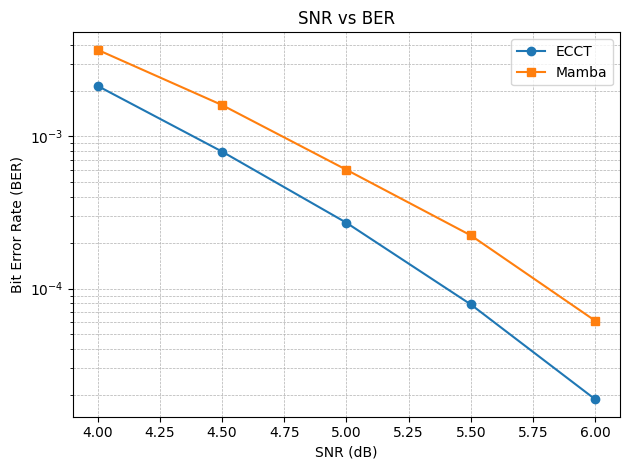

In [4]:


plot_snr_vs_ber_two_files(json_path_1="ecct_results.json", 
                          json_path_2="./results/run_5/DB8DD6598C02D4D5C69BA9EF528B588A/validation_pure_mamba_with_inf_time.json",
                          label_1="ECCT",
                          label_2="Mamba"
                          )